# **Data Cleaning & Preprocessing - Design and develop a structured business database and generate insights from it to support decision-making**

# Imports Libraries & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('All libraries loaded successfully.')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')

All libraries loaded successfully.
   pandas  : 2.3.3
   numpy   : 2.3.5


# Load All Sheets

In [3]:
FILE_PATH = '../data/retail_sales_dataset.xlsx'   

sheets = pd.read_excel(FILE_PATH, sheet_name=None)

df_customers     = sheets['Customers'].copy()
df_products      = sheets['Products'].copy()
df_stores        = sheets['Stores'].copy()
df_transactions  = sheets['Transactions'].copy()

print('Dataset loaded successfully!')
print(f'   Customers    : {df_customers.shape[0]:>6} rows × {df_customers.shape[1]} cols')
print(f'   Products     : {df_products.shape[0]:>6} rows × {df_products.shape[1]} cols')
print(f'   Stores       : {df_stores.shape[0]:>6} rows × {df_stores.shape[1]} cols')
print(f'   Transactions : {df_transactions.shape[0]:>6} rows × {df_transactions.shape[1]} cols')

Dataset loaded successfully!
   Customers    :    200 rows × 7 cols
   Products     :     50 rows × 6 cols
   Stores       :      5 rows × 4 cols
   Transactions :   5000 rows × 8 cols


# Explore Customers

In [4]:
print('='*60)
print('TABLE: Customers')
print('='*60)
print('\nFirst 5 rows:')
display(df_customers.head())

print('\nData Types & Non-Null Counts:')
df_customers.info()

print('\nMissing Values:')
print(df_customers.isnull().sum())

print('\nDuplicate Rows:', df_customers.duplicated().sum())
print('\nGender Distribution:')
print(df_customers['Gender'].value_counts())

TABLE: Customers

First 5 rows:


,CustomerID,FirstName,LastName,Gender,BirthDate,City,JoinDate
0,C001,Michael,Davis,M,1996-09-11,Osborneport,2022-09-25
1,C002,Michael,Miller,M,1959-08-18,New Gabrielleport,2020-11-03
2,C003,Carol,Hays,F,2005-04-19,Port Allen,2024-02-12
3,C004,Joseph,Ward,M,1992-06-16,East Edgarborough,2024-09-09
4,C005,Jamie,Salinas,M,1992-06-18,Port Kimberly,2022-02-24



Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   CustomerID  200 non-null    object        
 1   FirstName   200 non-null    object        
 2   LastName    200 non-null    object        
 3   Gender      200 non-null    object        
 4   BirthDate   200 non-null    datetime64[ns]
 5   City        200 non-null    object        
 6   JoinDate    200 non-null    datetime64[ns]
dtypes: datetime64[ns](2), object(5)
memory usage: 11.1+ KB

Missing Values:
CustomerID    0
FirstName     0
LastName      0
Gender        0
BirthDate     0
City          0
JoinDate      0
dtype: int64

Duplicate Rows: 0

Gender Distribution:
Gender
M    113
F     87
Name: count, dtype: int64


# Explore Products

In [5]:
print('='*60)
print('TABLE: Products')
print('='*60)
display(df_products.head())

print('\nCategories & SubCategories:')
print(df_products.groupby('Category')['SubCategory'].unique())

print('\nPrice Statistics:')
display(df_products[['UnitPrice','CostPrice']].describe())

anomaly = df_products[df_products['CostPrice'] >= df_products['UnitPrice']]
print(f'\nRows where CostPrice >= UnitPrice (anomaly check): {len(anomaly)}')
if len(anomaly) > 0:
    display(anomaly)

TABLE: Products


,ProductID,ProductName,Category,SubCategory,UnitPrice,CostPrice
0,P001,Like Camera,Electronics,Camera,1673.69,1323.38
1,P002,Audience Television,Electronics,Television,818.76,527.62
2,P003,Here Footwear,Fashion,Footwear,337.63,169.03
3,P004,Four Accessories,Fashion,Accessories,1853.77,1363.52
4,P005,Knowledge Bags,Fashion,Bags,1396.22,1004.09



Categories & SubCategories:
Category
Electronics    [Camera, Television, Smartphone, Headphones, L...
Fashion         [Footwear, Accessories, Bags, Watches, Clothing]
Groceries                    [Fruits, Snacks, Dairy, Vegetables]
Name: SubCategory, dtype: object

Price Statistics:


,UnitPrice,CostPrice
count,50.00,50.00
mean,1028.25,696.39
std,592.55,430.38
min,25.57,15.28
25%,428.32,265.35
50%,1179.23,784.93
75%,1486.82,1000.14
max,1952.65,1451.27



Rows where CostPrice >= UnitPrice (anomaly check): 0


# Explore Stores

In [6]:
print('='*60)
print('TABLE: Stores')
print('='*60)
display(df_stores)

print('\nRegion Distribution:')
print(df_stores['Region'].value_counts())

TABLE: Stores


,StoreID,StoreName,City,Region
0,S001,MegaMart Jimenezborough,Jimenezborough,South
1,S002,MegaMart Peckmouth,Peckmouth,East
2,S003,MegaMart New Michele,New Michele,West
3,S004,MegaMart Brianahaven,Brianahaven,North
4,S005,MegaMart Johnmouth,Johnmouth,East



Region Distribution:
Region
East     2
South    1
West     1
North    1
Name: count, dtype: int64


# Explore Transactions

In [7]:
print('='*60)
print('TABLE: Transactions')
print('='*60)
display(df_transactions.head())

print('\nData Types:')
df_transactions.info()

print('\nNumeric Summary:')
display(df_transactions[['Quantity','Discount']].describe())

print('\nPayment Method Counts:')
print(df_transactions['PaymentMethod'].value_counts())

print('\nDate Range:')
print(f'   Earliest : {df_transactions["Date"].min().date()}')
print(f'   Latest   : {df_transactions["Date"].max().date()}')

TABLE: Transactions


,TransactionID,Date,CustomerID,ProductID,StoreID,Quantity,Discount,PaymentMethod
0,T00001,2024-06-18,C160,P014,S003,1,0.10,Bank Transfer
1,T00002,2023-11-02,C171,P030,S004,3,0.15,Bank Transfer
2,T00003,2024-03-28,C142,P002,S002,2,0.15,Mobile Money
3,T00004,2024-06-15,C174,P050,S002,5,0.10,Mobile Money
4,T00005,2024-08-29,C141,P036,S001,3,0.10,Credit Card



Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   TransactionID  5000 non-null   object        
 1   Date           5000 non-null   datetime64[ns]
 2   CustomerID     5000 non-null   object        
 3   ProductID      5000 non-null   object        
 4   StoreID        5000 non-null   object        
 5   Quantity       5000 non-null   int64         
 6   Discount       5000 non-null   float64       
 7   PaymentMethod  5000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 312.6+ KB

Numeric Summary:


,Quantity,Discount
count,5000.00,5000.00
mean,2.99,0.08
std,1.41,0.06
min,1.00,0.00
25%,2.00,0.05
50%,3.00,0.10
75%,4.00,0.15
max,5.00,0.15



Payment Method Counts:
PaymentMethod
Cash             1284
Credit Card      1281
Mobile Money     1276
Bank Transfer    1159
Name: count, dtype: int64

Date Range:
   Earliest : 2023-09-10
   Latest   : 2025-09-09


# Referential Integrity Check

In [8]:
valid_customers = set(df_customers['CustomerID'])
valid_products  = set(df_products['ProductID'])
valid_stores    = set(df_stores['StoreID'])

orphan_cust  = df_transactions[~df_transactions['CustomerID'].isin(valid_customers)]
orphan_prod  = df_transactions[~df_transactions['ProductID'].isin(valid_products)]
orphan_store = df_transactions[~df_transactions['StoreID'].isin(valid_stores)]

print('Referential Integrity Results:')
print(f'   Orphan CustomerIDs : {len(orphan_cust)}')
print(f'   Orphan ProductIDs  : {len(orphan_prod)}')
print(f'   Orphan StoreIDs    : {len(orphan_store)}')

if len(orphan_cust) == 0 and len(orphan_prod) == 0 and len(orphan_store) == 0:
    print('\nAll foreign keys are valid — No referential integrity issues found!')
else:
    print('\nIntegrity issues found — review above rows.')

Referential Integrity Results:
   Orphan CustomerIDs : 0
   Orphan ProductIDs  : 0
   Orphan StoreIDs    : 0

All foreign keys are valid — No referential integrity issues found!


# EDA Visualizations

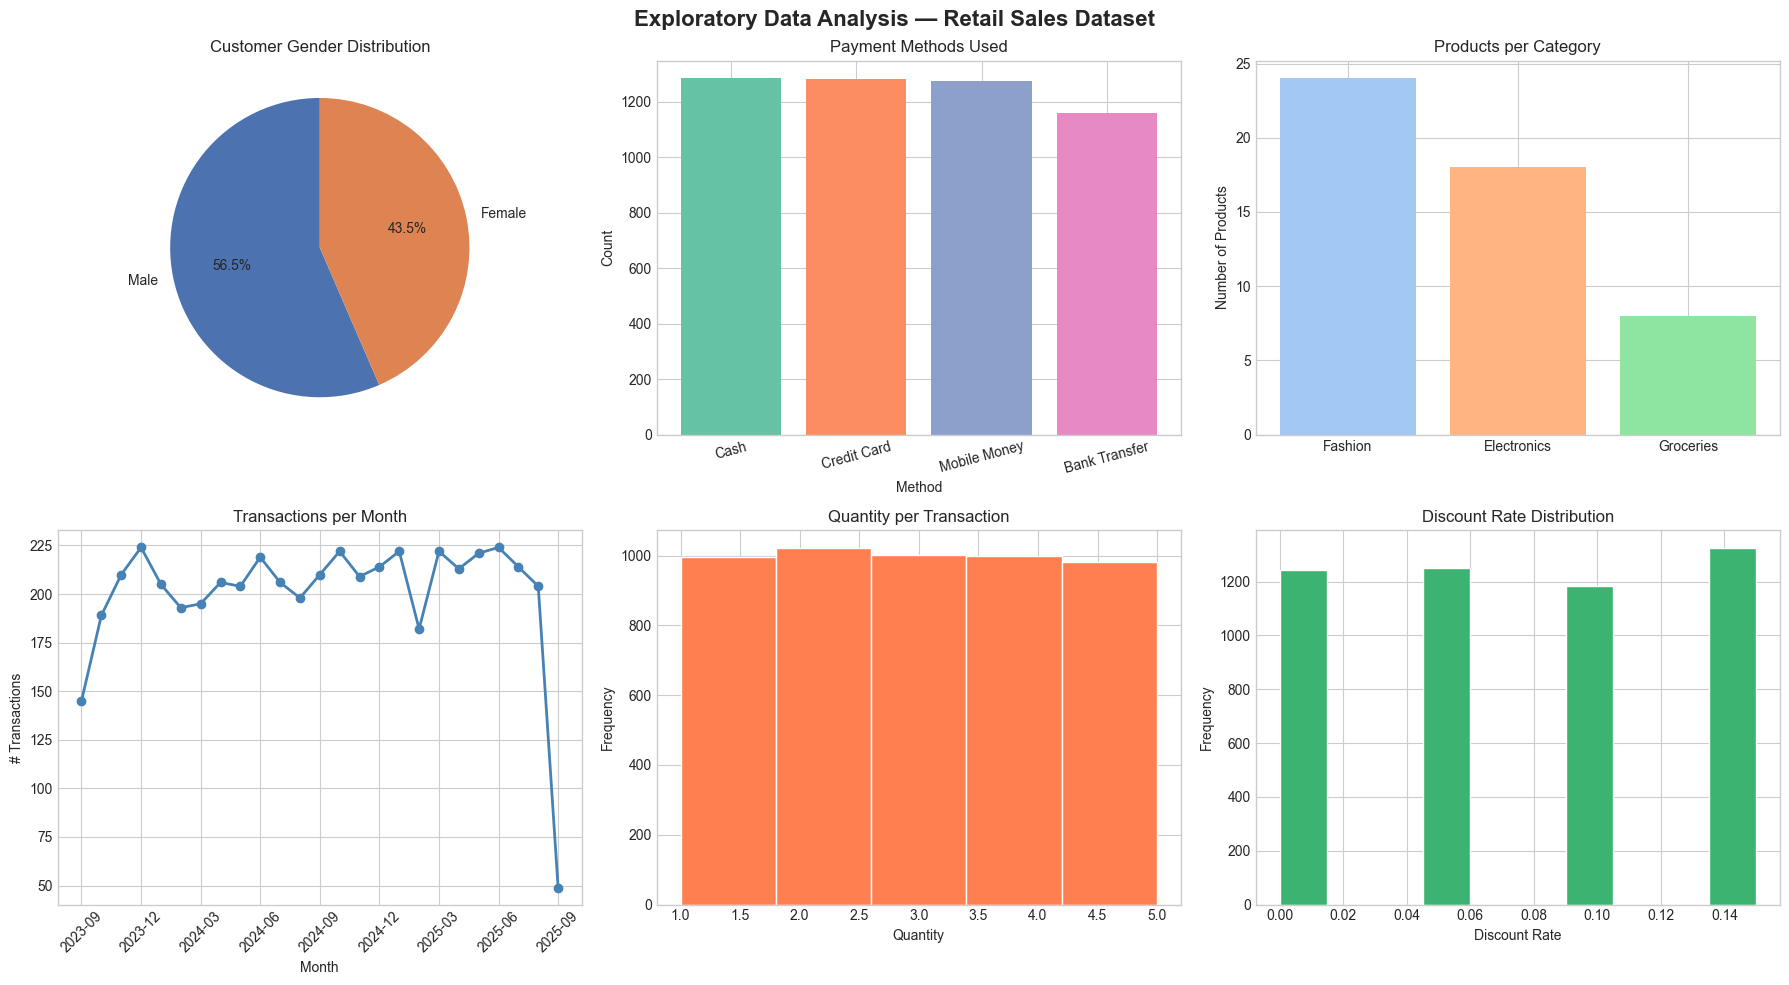

charts/EDA plots saved as eda_overview.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis — Retail Sales Dataset', fontsize=16, fontweight='bold')

# 1. Gender distribution of customers
gender_counts = df_customers['Gender'].value_counts()
axes[0,0].pie(gender_counts, labels=['Male','Female'], autopct='%1.1f%%',
              colors=['#4C72B0','#DD8452'], startangle=90)
axes[0,0].set_title('Customer Gender Distribution')

# 2. Payment method bar chart
pm = df_transactions['PaymentMethod'].value_counts()
axes[0,1].bar(pm.index, pm.values, color=sns.color_palette('Set2', 4))
axes[0,1].set_title('Payment Methods Used')
axes[0,1].set_xlabel('Method')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Product category count
cat = df_products['Category'].value_counts()
axes[0,2].bar(cat.index, cat.values, color=sns.color_palette('pastel', 3))
axes[0,2].set_title('Products per Category')
axes[0,2].set_ylabel('Number of Products')

# 4. Transactions per month
df_transactions['Month'] = df_transactions['Date'].dt.to_period('M')
monthly = df_transactions.groupby('Month').size()
monthly.index = monthly.index.astype(str)
axes[1,0].plot(monthly.index, monthly.values, marker='o', color='steelblue', linewidth=2)
axes[1,0].set_title('Transactions per Month')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('# Transactions')
tick_positions = range(0, len(monthly.index), 3)
axes[1,0].set_xticks(list(tick_positions))
axes[1,0].set_xticklabels([list(monthly.index)[i] for i in tick_positions], rotation=45)

# 5. Quantity distribution
axes[1,1].hist(df_transactions['Quantity'], bins=5, color='coral', edgecolor='white')
axes[1,1].set_title('Quantity per Transaction')
axes[1,1].set_xlabel('Quantity')
axes[1,1].set_ylabel('Frequency')

# 6. Discount distribution
axes[1,2].hist(df_transactions['Discount'], bins=10, color='mediumseagreen', edgecolor='white')
axes[1,2].set_title('Discount Rate Distribution')
axes[1,2].set_xlabel('Discount Rate')
axes[1,2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../charts/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('charts/EDA plots saved as eda_overview.png')

# Clean Customers

In [13]:
cust = df_customers.copy()
print('Cleaning Customers table...')
print(f'   Original shape: {cust.shape}')

# Strip whitespace
for col in cust.select_dtypes(include='object').columns:
    cust[col] = cust[col].str.strip()

# Standardize Gender
cust['Gender'] = cust['Gender'].str.upper().str.strip()
invalid_gender = cust[~cust['Gender'].isin(['M','F'])]
print(f'   Invalid Gender values: {len(invalid_gender)}')

# Title-case names
cust['FirstName'] = cust['FirstName'].str.title()
cust['LastName']  = cust['LastName'].str.title()

# Create FullName
cust['FullName'] = cust['FirstName'] + ' ' + cust['LastName']

# Ensure datetime types
cust['BirthDate'] = pd.to_datetime(cust['BirthDate'])
cust['JoinDate']  = pd.to_datetime(cust['JoinDate'])

# Calculate Age
today = pd.Timestamp.today()
cust['Age'] = ((today - cust['BirthDate']).dt.days / 365.25).astype(int)

# Sanity check age
invalid_age = cust[(cust['Age'] < 16) | (cust['Age'] > 100)]
print(f'   Customers with unusual age (<16 or >100): {len(invalid_age)}')
if len(invalid_age) > 0:
    display(invalid_age[['CustomerID','FirstName','BirthDate','Age']])

# JoinDate logic check
cust['MinJoinAge'] = cust['BirthDate'] + pd.DateOffset(years=16)
wrong_join = cust[cust['JoinDate'] < cust['MinJoinAge']]
print(f'   Customers who joined before age 16: {len(wrong_join)}')
cust.drop(columns=['MinJoinAge'], inplace=True)

# Remove duplicates
before = len(cust)
cust.drop_duplicates(inplace=True)
print(f'   Duplicates removed: {before - len(cust)}')

# Reorder columns
cust = cust[['CustomerID','FirstName','LastName','FullName','Gender',
             'BirthDate','Age','City','JoinDate']]

print(f'   Cleaned shape: {cust.shape}')
print('\nCustomers cleaned. Preview:')
display(cust.head())

Cleaning Customers table...
   Original shape: (200, 7)
   Invalid Gender values: 0
   Customers with unusual age (<16 or >100): 0
   Customers who joined before age 16: 5
   Duplicates removed: 0
   Cleaned shape: (200, 9)

Customers cleaned. Preview:


,CustomerID,FirstName,LastName,FullName,Gender,BirthDate,Age,City,JoinDate
0,C001,Michael,Davis,Michael Davis,M,1996-09-11,29,Osborneport,2022-09-25
1,C002,Michael,Miller,Michael Miller,M,1959-08-18,66,New Gabrielleport,2020-11-03
2,C003,Carol,Hays,Carol Hays,F,2005-04-19,20,Port Allen,2024-02-12
3,C004,Joseph,Ward,Joseph Ward,M,1992-06-16,33,East Edgarborough,2024-09-09
4,C005,Jamie,Salinas,Jamie Salinas,M,1992-06-18,33,Port Kimberly,2022-02-24


# Clean Products

In [14]:
prod = df_products.copy()
print('Cleaning Products table...')
print(f'   Original shape: {prod.shape}')

# Strip whitespace
for col in prod.select_dtypes(include='object').columns:
    prod[col] = prod[col].str.strip()

# Title-case
prod['ProductName'] = prod['ProductName'].str.title()
prod['Category']    = prod['Category'].str.title()
prod['SubCategory'] = prod['SubCategory'].str.title()

# Validate prices
invalid_price = prod[prod['CostPrice'] >= prod['UnitPrice']]
print(f'   Products where CostPrice >= UnitPrice: {len(invalid_price)}')
if len(invalid_price) > 0:
    display(invalid_price)

# Calculate ProfitMargin
prod['ProfitMargin'] = ((prod['UnitPrice'] - prod['CostPrice']) / prod['UnitPrice'] * 100).round(2)

# Round prices
prod['UnitPrice']  = prod['UnitPrice'].round(2)
prod['CostPrice']  = prod['CostPrice'].round(2)

# Remove duplicates
before = len(prod)
prod.drop_duplicates(inplace=True)
print(f'   Duplicates removed: {before - len(prod)}')

# Reorder columns
prod = prod[['ProductID','ProductName','Category','SubCategory',
             'UnitPrice','CostPrice','ProfitMargin']]

print(f'   Cleaned shape: {prod.shape}')
print('\nProducts cleaned. Preview:')
display(prod.head())

print('\nProfit Margin Summary:')
display(prod['ProfitMargin'].describe())

Cleaning Products table...
   Original shape: (50, 6)
   Products where CostPrice >= UnitPrice: 0
   Duplicates removed: 0
   Cleaned shape: (50, 7)

Products cleaned. Preview:


,ProductID,ProductName,Category,SubCategory,UnitPrice,CostPrice,ProfitMargin
0,P001,Like Camera,Electronics,Camera,1673.69,1323.38,20.93
1,P002,Audience Television,Electronics,Television,818.76,527.62,35.56
2,P003,Here Footwear,Fashion,Footwear,337.63,169.03,49.94
3,P004,Four Accessories,Fashion,Accessories,1853.77,1363.52,26.45
4,P005,Knowledge Bags,Fashion,Bags,1396.22,1004.09,28.09



Profit Margin Summary:


count   50.00
mean    33.59
std      9.31
min     20.38
25%     25.21
50%     33.28
75%     40.97
max     49.94
Name: ProfitMargin, dtype: float64

# Clean Stores

In [15]:
stores = df_stores.copy()
print('Cleaning Stores table...')
print(f'   Original shape: {stores.shape}')

# Strip whitespace
for col in stores.select_dtypes(include='object').columns:
    stores[col] = stores[col].str.strip()

# Title-case
stores['StoreName'] = stores['StoreName'].str.title()
stores['City']      = stores['City'].str.title()
stores['Region']    = stores['Region'].str.title()

# Validate Region
expected_regions = {'North', 'South', 'East', 'West', 'Central'}
invalid_region = stores[~stores['Region'].isin(expected_regions)]
print(f'   Unexpected Region values: {len(invalid_region)}')

# Remove duplicates
before = len(stores)
stores.drop_duplicates(inplace=True)
print(f'   Duplicates removed: {before - len(stores)}')

print(f'   Cleaned shape: {stores.shape}')
print('\nStores cleaned. Full table:')
display(stores)

Cleaning Stores table...
   Original shape: (5, 4)
   Unexpected Region values: 0
   Duplicates removed: 0
   Cleaned shape: (5, 4)

Stores cleaned. Full table:


,StoreID,StoreName,City,Region
0,S001,Megamart Jimenezborough,Jimenezborough,South
1,S002,Megamart Peckmouth,Peckmouth,East
2,S003,Megamart New Michele,New Michele,West
3,S004,Megamart Brianahaven,Brianahaven,North
4,S005,Megamart Johnmouth,Johnmouth,East


# Clean Transactions

In [16]:
trans = df_transactions.copy()
print('Cleaning Transactions table...')
print(f'   Original shape: {trans.shape}')

# Strip whitespace
for col in trans.select_dtypes(include='object').columns:
    trans[col] = trans[col].str.strip()

# Ensure datetime
trans['Date'] = pd.to_datetime(trans['Date'])

# Validate Quantity
invalid_qty = trans[trans['Quantity'] <= 0]
print(f'   Rows with Quantity <= 0: {len(invalid_qty)}')

# Validate Discount
invalid_disc = trans[(trans['Discount'] < 0) | (trans['Discount'] > 1)]
print(f'   Rows with invalid Discount: {len(invalid_disc)}')

# Standardize PaymentMethod
trans['PaymentMethod'] = trans['PaymentMethod'].str.title()
print(f'   Payment Methods found: {trans["PaymentMethod"].unique().tolist()}')

# Calculate TotalAmount
trans = trans.merge(prod[['ProductID', 'UnitPrice']], on='ProductID', how='left')
trans['TotalAmount'] = (trans['UnitPrice'] * trans['Quantity'] * (1 - trans['Discount'])).round(2)
trans.drop(columns=['UnitPrice'], inplace=True)

# Drop Month helper column if it exists
if 'Month' in trans.columns:
    trans.drop(columns=['Month'], inplace=True)

# Check duplicate TransactionIDs
dup_ids = trans[trans.duplicated('TransactionID', keep=False)]
print(f'   Duplicate TransactionIDs: {len(dup_ids)}')
trans.drop_duplicates(subset='TransactionID', keep='first', inplace=True)

# Reorder columns
trans = trans[['TransactionID','Date','CustomerID','ProductID','StoreID',
               'Quantity','Discount','PaymentMethod','TotalAmount']]

print(f'   Cleaned shape: {trans.shape}')
print('\nTransactions cleaned. Preview:')
display(trans.head())

print('\nTotalAmount Summary:')
display(trans['TotalAmount'].describe())

Cleaning Transactions table...
   Original shape: (5000, 9)
   Rows with Quantity <= 0: 0
   Rows with invalid Discount: 0
   Payment Methods found: ['Bank Transfer', 'Mobile Money', 'Credit Card', 'Cash']
   Duplicate TransactionIDs: 0
   Cleaned shape: (5000, 9)

Transactions cleaned. Preview:


,TransactionID,Date,CustomerID,ProductID,StoreID,Quantity,Discount,PaymentMethod,TotalAmount
0,T00001,2024-06-18,C160,P014,S003,1,0.10,Bank Transfer,1208.48
1,T00002,2023-11-02,C171,P030,S004,3,0.15,Bank Transfer,74.56
2,T00003,2024-03-28,C142,P002,S002,2,0.15,Mobile Money,1391.89
3,T00004,2024-06-15,C174,P050,S002,5,0.10,Mobile Money,4700.88
4,T00005,2024-08-29,C141,P036,S001,3,0.10,Credit Card,4053.94



TotalAmount Summary:


count   5000.00
mean    2860.38
std     2265.96
min       21.73
25%     1043.15
50%     2156.12
75%     4451.31
max     9763.25
Name: TotalAmount, dtype: float64

In [21]:
print('='*60)
print(' FINAL VALIDATION REPORT')
print('='*60)

# Create a Dictionary of Tables to store all datasets in one dictionary
tables = {
    'Customers'   : cust,
    'Products'    : prod,
    'Stores'      : stores,
    'Transactions': trans 
}

for name, df in tables.items():  # Loop through each table
    nulls = df.isnull().sum().sum()  # Count Missing Values
    dups  = df.duplicated().sum()   # Count Duplicate Values
    print(f'\n  {name}')
    print(f'    Rows         : {len(df)}')
    print(f'    Columns      : {len(df.columns)}')
    print(f'    Null values  : {nulls}   {"⚠️" if nulls > 0 else "✅"}')  # Display Warning or Success
    print(f'    Duplicates   : {dups}   {"⚠️" if dups > 0 else "✅"}')  # Display Warning or Success

# Checks relationships between tables
print('\n  Referential Integrity (post-cleaning):')
c_ids = set(cust['CustomerID'])
p_ids = set(prod['ProductID'])
s_ids = set(stores['StoreID'])
print(f'    Orphan CustomerIDs : {trans[~trans["CustomerID"].isin(c_ids)].shape[0]}  ✅')
print(f'    Orphan ProductIDs  : {trans[~trans["ProductID"].isin(p_ids)].shape[0]}  ✅')
print(f'    Orphan StoreIDs    : {trans[~trans["StoreID"].isin(s_ids)].shape[0]}  ✅')

 FINAL VALIDATION REPORT

  Customers
    Rows         : 200
    Columns      : 9
    Null values  : 0   ✅
    Duplicates   : 0   ✅

  Products
    Rows         : 50
    Columns      : 7
    Null values  : 0   ✅
    Duplicates   : 0   ✅

  Stores
    Rows         : 5
    Columns      : 4
    Null values  : 0   ✅
    Duplicates   : 0   ✅

  Transactions
    Rows         : 5000
    Columns      : 9
    Null values  : 0   ✅
    Duplicates   : 0   ✅

  Referential Integrity (post-cleaning):
    Orphan CustomerIDs : 0  ✅
    Orphan ProductIDs  : 0  ✅
    Orphan StoreIDs    : 0  ✅


# Export Cleaned CSVs

In [23]:
# Output directory
OUTPUT_DIR = '../data/cleaned_data'

# Format dates for SQL Server
cust_export = cust.copy()
cust_export['BirthDate'] = cust_export['BirthDate'].dt.strftime('%Y-%m-%d')
cust_export['JoinDate']  = cust_export['JoinDate'].dt.strftime('%Y-%m-%d')

trans_export = trans.copy()
trans_export['Date'] = trans_export['Date'].dt.strftime('%Y-%m-%d')

# Save cleaned files
cust_export.to_csv( f'{OUTPUT_DIR}/customers_clean.csv',     index=False)
prod.to_csv(        f'{OUTPUT_DIR}/products_clean.csv',      index=False)
stores.to_csv(      f'{OUTPUT_DIR}/stores_clean.csv',        index=False)
trans_export.to_csv(f'{OUTPUT_DIR}/transactions_clean.csv',  index=False)

print('Cleaned CSV files exported to folder: data/cleaned_data/')
print()

# Show Summary
for fname in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath)
    rows  = sum(1 for _ in open(fpath)) - 1
    
    print(f'   {fname:<30} {rows:>5} rows   {size/1024:.1f} KB')

Cleaned CSV files exported to folder: data/cleaned_data/

   customers_clean.csv              200 rows   14.4 KB
   products_clean.csv                50 rows   3.0 KB
   stores_clean.csv                   5 rows   0.2 KB
   transactions_clean.csv          5000 rows   288.4 KB


# Summary Report

In [24]:
print('='*65)
print('  RETAIL SALES DATABASE — PREPROCESSING SUMMARY REPORT')
print('='*65)
print(f'  Generated  : {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print()
print('  DATASET OVERVIEW')
print(f'  - Total Customers    : {len(cust)}')
print(f'  - Total Products     : {len(prod)}')
print(f'  - Total Stores       : {len(stores)}')
print(f'  - Total Transactions : {len(trans)}')
print(f'  - Date Range         : {trans["Date"].min()} → {trans["Date"].max()}')
print()
print('  CLEANING ACTIONS PERFORMED')
print('  Customers:')
print('    [+] FullName derived column added')
print('    [+] Age calculated from BirthDate')
print('    [+] Gender standardized to M/F')
print('    [+] Dates validated and formatted')
print('    [+] Whitespace trimmed, names title-cased')
print('  Products:')
print('    [+] ProfitMargin % calculated')
print('    [+] Prices validated (UnitPrice > CostPrice)')
print('    [+] Category/SubCategory text standardized')
print('  Stores:')
print('    [+] Region and City text standardized')
print('  Transactions:')
print('    [+] TotalAmount calculated (Price × Qty × (1-Discount))')
print('    [+] Discount range validated (0–1)')
print('    [+] Duplicate TransactionIDs checked')
print('    [+] PaymentMethod text standardized')
print()
print('  BUSINESS KEY METRICS')
print(f'  - Total Revenue      : ${trans["TotalAmount"].sum():>12,.2f}')
print(f'  - Avg Transaction    : ${trans["TotalAmount"].mean():>12,.2f}')
print(f'  - Max Transaction    : ${trans["TotalAmount"].max():>12,.2f}')
print(f'  - Product Categories : {prod["Category"].nunique()}')
print(f'  - Avg Profit Margin  : {prod["ProfitMargin"].mean():.1f}%')
print()
print('  OUTPUT FILES')
print('  - cleaned_data/customers_clean.csv')
print('  - cleaned_data/products_clean.csv')
print('  - cleaned_data/stores_clean.csv')
print('  - cleaned_data/transactions_clean.csv')
print('='*65)

  RETAIL SALES DATABASE — PREPROCESSING SUMMARY REPORT
  Generated  : 2026-03-10 12:46

  DATASET OVERVIEW
  - Total Customers    : 200
  - Total Products     : 50
  - Total Stores       : 5
  - Total Transactions : 5000
  - Date Range         : 2023-09-10 00:00:00 → 2025-09-09 00:00:00

  CLEANING ACTIONS PERFORMED
  Customers:
    [+] FullName derived column added
    [+] Age calculated from BirthDate
    [+] Gender standardized to M/F
    [+] Dates validated and formatted
    [+] Whitespace trimmed, names title-cased
  Products:
    [+] ProfitMargin % calculated
    [+] Prices validated (UnitPrice > CostPrice)
    [+] Category/SubCategory text standardized
  Stores:
    [+] Region and City text standardized
  Transactions:
    [+] TotalAmount calculated (Price × Qty × (1-Discount))
    [+] Discount range validated (0–1)
    [+] Duplicate TransactionIDs checked
    [+] PaymentMethod text standardized

  BUSINESS KEY METRICS
  - Total Revenue      : $14,301,903.57
  - Avg Transaction 